# chapter 7. 합성곱 신경망(CNN)
이번 장의 주제는 `합성곱 신경망(convolutional neural network)`\
CNN은 이미지 인식과 음성 인식 등 다양한 곳에서 사용되는데, 특히 이미지 인식 분야에서 딥러닝을 활용한 기법은 거의 CNN을 기초로 함

> 합성곱은 두 함수 중 하나를 반전(reverse), 이동(shift)시켜가며 나머지 함수와의 곱을 연이어 적분함

## 7.1 전체 구조
CNN의 신경망 구조를 살펴보며 전체 틀을 이해해볼 것임\
CNN도 지금까지 본 신경망과 같이 레고 블록처럼 계층을 조합하여 만들 수 있음\
다만, `합성곱 계층(convolutional layer)`와 `풀링 계층(pooling layer)`이 새롭게 등장함\
이 계층들을 어떻게 조합하여 CNN을 만드는지를 먼저 볼 것임

지금까지 본 신경망은 인접하는 계층의 모든 뉴런과 결합되어 있었음\

이를 `완전연결(fully-connected, 전결합)`이라고 하며 완전히 연결된 계층을 `Affine 계층`이라는 이름으로 구현하였음\
이 Affine 계층을 사용하면 가령 층이 5개인 완전연결 신경망은 아래와 같이 구현 가능
<br>

<img src="../image/ch7_affine_architecture.png" width="800" style="display:block; margin:auto;">

위 그림과 같이 완전연결 신경망은 Affine 계층 뒤에 활성화 함수를 갖는 ReLU 계층(혹은 Sigmoid 계층)이 이어짐\
이 그림에서는 Affine-ReLU 조합이 4개가 쌓였고, 마지막 5번째 층은 Affine 계층에 이어 소프트맥스 계층에서 최종 결과(확률)를 출력\

CNN의 구조는 아래와 같이 구현 가능
<br>

<img src="../image/ch7_cnn_architecture.jpg" width="800" style="display:block; margin:auto;">

CNN에서는 새로운 '합성곱 계층(Conv)'과 '풀링 계층(Pooling)'이 추가됨\
CNN의 계층은 'Conv-ReLU-(Pooling)'흐름으로 연결됨(풀링 계층은 생략하기도 함)\
CNN에서 주목할 다른 점은 출력에 가까운 층에서는 지금까지의 'Affine-ReLU'구성을 사용할 수 있다는 것임\
또, 마지막 출력 계층에서는 'Affine-Softmax'조합을 그대로 사용하며, 일반적인 CNN에서 흔히 볼 수 있는 구성임

## 7.2 합성곱 계층
CNN에서는 `패딩(padding)`, `스트라이드(stride)` 등 CNN 고유의 용어가 등장함\
또, 각 계층 사이에는 3차원 데이터같이 입체적인 데이터가 흐른다는 점에서 완전연결 신경망과 다름\

### 7.2.1 완전연결 계층의 문제점
완전연결 계층에서는 인접하는 계층의 뉴런이 모두 연결되고 출력의 수는 임의로 정할 수 있음\
완전연결 계층의 문제점은 '데이터의 형상이 무시'된다는 것임\
입력 데이터가 이미지인 경우를 예로 들면, 이미지는 통상 세로, 가로, 채널(색상)로 구성된 3차원 데이터임\
그러나 완전연결 계층에 입력할 때는 3차원 데이터를 평평한 1차원 데이터로 평탄화해줘야 함\
MNIST 데이터셋을 사용한 사례에서는 형상이 (1, 28, 28)인 이미지(1채널, 세로 28픽셀, 가로 28픽셀)를 1줄로 세운 784개의 데이터를 첫 Affine 계층에 입력하였음

이미지는 3차원 형상이며, 이 형상에는 공간적 정보가 담겨 있음\
예를 들어 공간적으로 가까운 픽셀은 값이 비슷하거나, RGB의 각 채널은 서로 밀접하게 관련되어 있거나, 거리가 먼 픽셀끼리는 별 연관이 없는 등 3차원 속에서 의미를 갖는 본질적인 패턴이 숨어 있을 것임\
그러나 완전연결 계층은 형상을 무시하고 모든 입력 데이터를 동등한 뉴런(같은 차원의 뉴런)으로 취급하여 형상에 담긴 정보를 살릴 수 없음

합성곱 계층은 형상을 유지하기에, 이미지도 3차원 데이터로 입력받으며, 마찬가지로 다음 계층에도 3차원 데이터로 전달함\
그래서 CNN에서는 이미지처럼 형상을 가진 데이터를 제대로 이해할 가능성이 있는 것임\
CNN에서는 합성곱 계층의 입출력 데이터를 `특징 맵(feature map)`이라고도 함\
합성곱 계층의 입력 데이터를 `입력 특징 맵(input feature map)`, 출력 데이터를 `출력 특징 맵(output feature map)`\
('입출력 데이터'와 '특징 맵'을 같은 의미로 사용함)

### 7.2.2 합성곱 연산
합성곱 계층에서 처리하는 `합성곱 연산`은 이미지 처리에서 말하는 `필터 연산`에 해당함\

<img src="../image/ch7_convproduct.png" width="800" style="display:block; margin:auto;">

위와 같이 합성곱 연산은 입력 데이터에 필터를 적용함\
이 예시에서 입력 데이터는 세로, 가로 방향의 형상을 가졌고, 필터 역시 세로, 가로 방향의 차원을 가짐\
데이터와 필터의 형상을(높이, 너비)로 표기하며 이 예시에서는 입력은 (4,4), 필터는 (3,3), 출력은 (2,2)가 됨\
문헌에 따라 필터를 `커널`이라 칭하기도 함

<img src="../image/ch7_cnn_op_order.png" width="400" style="display:block; margin:auto;">

합성곱 연산은 필터의 `윈도우(window)`를 일정 간격으로 이동해가며 입력 데이터에 적용함\
윈도우는 위 그림에서 회색 3x3 부분을 가리킴\
입력과 필터에서 대응하는 원소끼리 곱한 후 그 총합을 구함(이 계산을 `단일 곱셈-누산(fused multiply-add, FMA)`이라 함)\
그리고 그 결과를 출력의 해당 장소에 저장하며, 이 과정을 모든 장소에서 수행하면 합성곱 연산의 출력이 완성됨
완전연결 신경망에는 가중치 매개변수와 편향이 존재하지만, CNN에서는 필터의 매개변수가 그동안의 '가중치'에 해당하며 CNN에도 편향이 존재\
아래와 같이 편향은 필터를 적용한 후 데이터에 더해지며 편향은 항상 하나(1x1)만 존재함(필터를 적용한 모든 원소에 하나의 값을 더함) 
<img src="../image/ch7_cnn_op_order_bias.png" width="800" style="display:block; margin:auto;">

### 7.2.3 패딩
합성곱 연산을 수행하기 전에 입력 데이터 주변을 특정 값(예컨대 0)으로 채우기도 함\
이를 `패딩(padding)`이라 하며, 합성곱 연산에서 자주 이용하는 기법\
예를 들어 아래는 (4,4) 크기의 입력 데이터에 폭이 1인 패딩을 적용한 모습이며, 폭 1짜리 패딩은 입력 데이터 사방 1픽셀을 특정 값으로 채우는 것임(아래의 패딩은 점선으로 표시했으며 그 안의 값 '0'은 생략하였음)

<img src="../image/ch7_cnn_padding.png" width="800" style="display:block; margin:auto;">

처음에 크기가 (4,4)인 입력 데이터에 패딩이 추가되어 (6,6)이 되었음\
이 입력에 (3,3) 크기의 필터를 걸면 (4,4) 크기의 출력 데이터가 생성됨\
이 예시에서는 패딩을 1로 설정했지만, 2나 3 등 원하는 정수로 설정할 수 있음\
만약 패딩을 2로 설정하면 입력 데이터의 크기는 (8,8)이 되고, 3으로 설정하면 (10,10)이 됨

> 패딩은 주로 출력 크기를 조정할 목적으로 사용됨\
예를 들어 (4,4) 입력 데이터에 (3,3) 필터를 적용하면 출력은 (2,2)가 되어 입력보다 2만큼 줄어듬\
이는 합성곱 연산을 몇 번이나 되풀이하는 심층 신경망에서는 문제가 될 수 있음\
합성곱 연산을 거칠 때마다 크기가 작아지면 어느 시점에서는 출력 크기가 1이 되어 더 이상 합성곱 연산을 적용할 수 없게 됨\
이러한 사태를 막기 위해 패딩을 사용하는데, 앞 예시에서는 패딩의 폭을 1로 설정하니 입력과 같은 크기로 출력을 유지하였음\
한 마디로 입력 데이터의 공간적 크기를 고정한 채로 다음 계층에 전달할 수 있게 되었음

### 7.2.4 스트라이드
필터를 적용하는 위치의 간격을 `스트라이드(stride)`라고 함\
지금까지의 예시들은 모두 스트라이드가 1이었지만, 예를 들어 스트라이드를 2로 하면 필터를 적용하는 윈도우가 2칸씩 움직임

<img src="../image/ch7_cnn_stride.png" width="400" style="display:block; margin:auto;">

스트라이드를 2로 하니 출력은 (3,3)이 되는 것처럼 스트라이드를 키우면 출력 크기는 작아짐\
한편 패딩을 크게 하면 출력 크기가 커지는데, 이 관계를 수식화하면 다음과 같음\
입력 크기를 (H,W), 필터 크기를 (FH,FW), 출력 크기를 (OH, OW), 패딩을 P, 스트라이드를 S라 하면 출력 크기는 다음 식으로 계산됨
$$
OH = \frac{H + 2P - FH}{S} + 1
\\[10pt]
OW = \frac{W + 2P - FW}{S} + 1
$$
단순히 값을 대입하기만 하면 출력 크기를 구할 수 있으나 각 식이 정수로 나눠떨어지는 값이어야 한다는 점을 주의해야 함\
출력 크기가 정수가 아니면 오류 발생 등의 대응을 해야 하며 딥러닝 프레임워크 중에는 값이 나눠떨어지지 않을 때는 가장 가까운 정수로 반올림하는 등 특별히 에러를 내지 않고 진행하도록 구현하는 경우도 존재함

### 7.2.5 3차원 데이터의 합성곱 연산
지금까지 2차원 형상을 다루는 합성곱 연산을 살펴보았지만, 이미지만 해도 세로, 가로에 더해 채널까지 고려한 3차원 데이터임\
이번 절에서는 채널까지 고려한 3차원 데이터를 다루는 합성곱 연산을 살펴볼 것임
<!-- 가운데 정렬 -->
<img src="../image/ch7_cnn_example.png" width="600" style="display:block; margin:auto;">

위 그림은 3차원 데이터의 합성곱 연산의 예시인데, 2차원일 때와 비교하면, 길이 방향(채널 방향)으로 특징 맵이 늘어남\
채널쪽으로 특징 맵이 여러 개 있다면 입력 데이터와 필터의 합성곱 연산을 채널마다 수행하고, 그 결과를 더해서 하나의 출력을 얻음\
3차원의 합성곱 연산에서 주의할 점은 입력 데이터의 채널 수와 필터의 채널 수가 같아야 한다는 것\
필터 자체의 크기는 원하는 값으로 설정할 수 있음(단, 모든 채널의 필터가 같은 크기여야 함)

### 7.2.6 블록으로 생각하기
<img src="../image/ch7_conv_block.png" width="800" style="display:block; margin:auto;">

3차원 합성곱 연산은 데이터와 필터를 직육면체 블록이라고 생각하면 쉬우며, 블록은 위와 같은 3차원 직육면체임\
3차원 데이터를 다차원 배열로 나타낼 때는 (채널, 높이, 너비) 순서로 쓸 것임\
예를 들어 채널 수 C, 높이 H, 너비 W인 데이터의 형상은 (C, H, W)이며, 필터도 같은 순서로 씀((C, FH, FW))\
이 예시에서 출력 데이터는 한 장의 특징 맵임\
한 장의 특징 맵을 다른 말로 하면 채널이 1개인 특징 맵이라는 뜻임\
그렇다면 합성곱 연산의 출력으로 다수의 채널을 내보내려면 필터(가중치)를 다수 사용하는 것임

<img src="../image/ch7_several_filter.png" width="800" style="display:block; margin:auto;">

위와 같이 필터를 여러개 사용하면 출력 맵도 필터의 수 만큼 생성됨\
그리고 여러개의 맵을 모아 완성된 블록을 다음 계층으로 넘기겠다는 것이 CNN의 처리 흐름

이상에서 보듯 합성곱 연산에서는 필터의 수도 고려해야 함\
그런 이유로 필터의 가중치 데이터는 4차원 데이터이며(출력 채널 수, 입력 채널 수, 높이, 너비) 순으로 씀\
예를 들어 채널 수 3, 크기 5x5인 필터가 20개 있다면 (20, 3, 5, 5)로 작성함

합성곱 연산에도 완전연결 계층과 마찬가지로 편향이 쓰이는데 아래와 같음
<img src="../image/ch7_cnn_batch.png" width="800" style="display:block; margin:auto;">

편향은 채널 하나에 값 하나씩으로 구성되며 이 예시에서는 편햐으이 형상은 (FN, 1, 1)이고 필터의 출력 결과는 항상 (FN, OH, OW)\
이 두 블록을 더하면 편향의 각 값이 필터의 출력인 (FN, OH, OW) 블록의 대응 채널의 원소 모두에 더해짐\
참고로 형상이 다른 블록의 덧셈은 넘파이의 브로드캐스트 기능으로 쉽게 구현 가능함

### 7.2.7 배치 처리
신경망 처리에서는 입력 데이터를 한 덩어리로 묶어 배치로 처리하였음\
완전연결 신경망을 구현하면서는 이 방식을 지원하여 처리 효율을 높이고, 미니배치 방식의 학습도 지원하도록 하였음

합성곱 연산도 마찬가지로 배치 처리를 지원함\
각 계층을 흐르는 데이터의 차원을 하나 늘려 4차원 데이터로 저장함\
구체적으로는 데이터를 (데이터 수, 채널 수, 높이, 너비)순으로 저장함\
데이터가 N개 일때 배치 처리한다면 데이터 형태가 아래와 같이 됨

<img src="../image/ch7_cnn_batch.png" width="800" style="display:block; margin:auto;">

배치 처리 시의 데이터 흐름을 나타낸 그림을 보면 각 데이터의 선두에 배치용 차원을 추가하였음\
이처럼 데이터는 4차원 형상을 가진 채 각 계층을 타고 흐름\
여기에서 주의할 점은 신경망에 4차원 데이터가 하나 흐를 때마다 데이터 N개에 대한 합성곱 연산이 이뤄진다는 것인데, 즉 N회 분의 처리를 한 번에 수행하는 것임

## 7.3 풀링 계층
풀링은 세로, 가로 방향의 공간을 줄이는 연산이며 방식은 아래와 같음
<img src="../image/ch7_max_pooling.png" width="600" style="display:block; margin:auto;">

위 그림은 2x2 `최대 풀링(max pooling)`을 스트라이드 2로 처리하는 순서\
최대 풀링은 최댓값을 구하는 연산으로 '2x2'는 대상 영역의 크기를 뜻함\
즉 2x2 최대 풀링은 그림과 같이 2x2크기의 영역에서 가장 큰 원소 하나를 꺼냄\
스트라이드는 2로 설정했으므로 2x2윈도우가 원소 2칸 간격으로 이동하는데, 보통 풀링의 윈도우 크기와 스트라이드는 같은 값으로 설정\
예를 들어 윈도우가 3x3이면 스트라이드는 3으로, 윈도우가 4x4이면 스트라이드를 4로 설정함

> 풀링은 최대 풀링 외에도 평균 풀링 등이 있음\
최대 풀링은 대상 영역에서 최댓값을 취하는 연산인 반면, 평균 풀링은 대상 영역의 평균을 계산함\
이미지 인식 분야에서는 주로 최대 풀링을 사용함

### 7.3.1 풀링 계층의 특징
풀링 계층의 특징은 다음과 같이 3가지를 들 수 있음
* 학습해야 할 매개변수가 없음 : 풀링 계층은 합성곱 계층과 달리 학습해야 할 매개변수가 없으며 풀링은 대상 영역에서 최댓값이나 평균을 취하는 명확한 처리이므로 특별히 학습할 것이 없음

* 채널 수가 변하지 않음 : 풀링 연산은 입력 데이터의 채널 수 그대로 출력 데이터로 내보내는데 채널마다 독립적으로 계산하기 때문

* 입력의 변화에 영향을 적게 받음(강건성) : 입력 데이터가 조금 변해도 풀링의 결과는 잘 변하지 않는데, 예를 들어 데이터가 오른쪽으로 1칸씩 이동하여도 풀링이 그 차이를 흡수해 사라지게 함

## 7.4 합성곱/풀링 계층 구현하기
### 7.4.1 4차원 배열
예를 들어 데이터의 형상이 (10, 1, 28, 28)이라면 높이 28, 너비 28, 채널 1개인 데이터가 10개라는 의미

In [1]:
import numpy as np
x = np.random.rand(10, 1, 28, 28) # 무작위 데이터 생성
x.shape

(10, 1, 28, 28)

10개 중 첫 번째 데이터에 접근하려면 단순히 x[0]이라고 쓰고, 두 번째 데이터는 x[1] 위치에 존재함

In [2]:
x[0].shape

(1, 28, 28)

In [3]:
x[1].shape

(1, 28, 28)

첫 번째 데이터의 첫 채널 공간 데이터에 접근하려면 다음과 같이 작성함

In [5]:
x[0, 0] # 또는 x[0][0]

array([[0.16808093, 0.27437216, 0.26791543, 0.43210076, 0.31232565,
        0.54057925, 0.58454164, 0.00545517, 0.66690102, 0.05985566,
        0.86219806, 0.10995671, 0.00808885, 0.82829755, 0.13526838,
        0.83264036, 0.97859967, 0.83430131, 0.89143382, 0.80714147,
        0.07635623, 0.0131574 , 0.9325156 , 0.57875847, 0.19901177,
        0.05141156, 0.07508427, 0.53269846],
       [0.47269605, 0.09258909, 0.01260873, 0.63435498, 0.74223046,
        0.38125951, 0.09985182, 0.67812339, 0.26259332, 0.02554514,
        0.43302014, 0.13995237, 0.26520149, 0.74381873, 0.88406643,
        0.46020192, 0.24376194, 0.8577165 , 0.08203077, 0.21647862,
        0.84569417, 0.71379462, 0.71409596, 0.71416512, 0.31162352,
        0.0119062 , 0.17916361, 0.4888602 ],
       [0.90977693, 0.94539116, 0.48439838, 0.72844653, 0.29685288,
        0.62934979, 0.9052329 , 0.33127549, 0.15121756, 0.10450456,
        0.50021148, 0.16526672, 0.35652329, 0.12185505, 0.28575816,
        0.05073526, 0.1917

이처럼 CNN은 4차원 데이터를 다루기에 합성곱 연산의 구현은 복잡할 것 같지만 다음 절에서 설명하는 im2col이라는 '트릭'을 사용하면 문제를 단순하게 만들어줌

### 7.4.2 im2col로 데이터 전개하기
합성곱 연산을 그대로 구현하려면 for 문을 겹겹으로 사용해야하며, 넘파이에 for문을 사용하면 성능이 떨어진다는 단점이 있음\
그래서 for 문 대신 `im2col`이라는 편의 함수를 사용하여 구현할 것임

im2col은 입력 데이터를 필터링(가중치 계산)하기 좋게 전개하는(펼치는) 함수\
배치 안의 데이터 수까지 포함한 4차원 데이터를 2차원으로 변환함\
im2col은 필터링하기 좋게 입력 데이터를 전개하는데, 입력 데이터에서 필터를 적용하는 3차원 블록 영역을 한 줄로 늘어놓음
<img src="../image/ch7_im2col.png" width="600" style="display:block; margin:auto;">

위 그림에서는 보기 좋도록 스트라이드를 크게 잡아 필터의 적용 영역이 겹치지 않도록하였지만, 실제 상황에서는 영역이 겹치는 경우가 대부분\
필터 적용 영역이 겹치게 되면 im2col로 전개한 후의 원소 수가 원래 블록의 원소 수보다 많아짐\
그래서 im2col을 사용해 구현하면 메모리를 더 많이 소비하는 단점이 있지만 컴퓨터는 큰 행렬을 묶어서 계산하는 데 탁월함\
그래서 문제를 행렬 계산으로 만들면 선형 대수 라이브러리를 활용해 효율을 높일 수 있음

> im2col은 'image to column', 즉 '이미지에서 행렬로'라는 뜻

im2col로 입력 데이터를 전개한 다음에는 합성곱 계층의 필터(가중치)를 1열로 전개하고, 두 행렬의 곱을 계산하면 됨\
이는 완전연결 계층의 affine 계층에서 하는 일과 거의 같음

<img src="../image/ch7_im2col_op_order.png" width="800" style="display:block; margin:auto;">

위 그림과 같이 im2col 방식으로 출력한 결과는 2차원 행렬\
CNN은 데이터를 4차원 배열로 저장하므로 2차원인 출력 데이터를 4차원으로 변형(reshape)함

### 7.4.3 합성곱 계층 구현하기
im2col 함수의 인터페이스는 다음과 같음
```py
im2col(input_data, filter_h, filter_w, stride=1, pad=0)
```
* input_data : (데이터 수, 채널 수, 높이, 너비)의 4차원 배열로 이뤄진 입력 데이터

* filter_h : 필터의 높이

* filter_w : 필터의 너비

* stride : 스트라이드

* pad : 패딩

이 im2col은 '필터 크기', '스트라이드', '패딩'을 고려하여 입력 데이터를 2차원 배열로 전개함

In [6]:
import sys, os
sys.path.append(os.path.join(os.path.dirname(os.getcwd())))
from common.util import im2col

x1 = np.random.rand(1, 3, 7, 7) 
col1 = im2col(x1, 5, 5, stride=1, pad=0)
print(col1.shape)

x2 = np.random.rand(10, 3, 7, 7)
col2 = im2col(x2, 5, 5, stride=1, pad=0)
print(col2.shape)

(9, 75)
(90, 75)


2 가지 예를 보여주는데, 첫 번째는 배치 크기가 1(데이터 1개), 채널은 3개, 높이와 너비는 7x7의 데이터, 두 번째는 배치 크기만 10

im2col 함수를 적용한 두 경우 모두 2번째 차원의 원소는 75개이며, 이 값은 필터의 원소 수와 같음(채널 3개, 5x5 데이터)\
또한, 배치 크기가 1일 때는 im2col의 결과의 크기가 (9, 75)이고, 10일 때는 그 10배인 (90, 75)크기의 데이터가 저장됨\
이제 이 im2col을 사용하여 합성곱 계층을 구현하며, 합성곱 계층을 Convolution이라는 클래스로 구현할 것임

In [7]:
class Convolution:
    def __init__(self, W, b, stride=1, pad=0):
        self.W = W
        self.b = b
        self.stride = stride
        self.pad = pad
        
    def forward(self, x):
        FN, C, FH, FW = self.W.shape
        N, C, H, W = x.shape
        out_h = int(1 + (H + 2*self.pad - FH) / self.stride)
        out_w = int(1 + (W + 2*self.pad - FW) / self.stride)
        
        col = im2col(x, FH, FW, self.stride, self.pad)
        col_W = self.W.reshape(FN, -1).T # 필터 전개
        out = np.dot(col, col_W) + self.b
        
        out = out.reshape(N, out_h, out_w, -1).transpose(0,3,1,2)
        
        return out

합성곱 계층은 필터(가중치), 편향, 스트라이드, 패딩을 인수로 받아 초기화함\
필터는 (FN, C, FH, FW)의 4차원 형상이며 FN은 필터 개수, C는 채널, FH는 필터 높이, FW는 필터 너비\
col~out까지의 3줄에서 입력 데이터를 im2col로 전개하고 필터도 reshape을 사용해 2차원 배열로 전개한 후 두 행렬의 곱을 구함

필터를 전개하는 것은 각 필터 블록을 1줄로 펼쳐 세우는 것임\
여기에서 reshape의 두 번째 인수를 -1로 지정했는데, 이는 reshape이 제공하는 편의 기능임\
reshape에 -1을 지정하면 다차원 배열의 원소 수가 변환 후에도 똑같이 유지되도록 적절히 묶어줌\
예를 들어 앞 코드에서 (10,3,5,5)의 형상을 한 다차원 배열 W의 원소 수는 총 750개\
이 배열에 reshape(10,-1)을 호출하면 750개의 원소를 10묶음으로, 즉 형상이 (10, 75)인 배열로 만들어줌

다음으로 forward 구현의 마지막에서 출력 데이터를 적절한 형상으로 바꿔줌\
이때 넘파이의 transpose 함수를 사용하는데 이는 다차원 배열의 축 순서를 바꿔주는 함수임

<table> <tr> <td>형상</td> <td>(N, H, W, C)</td> <td>transpose</td> <td>(N, C, H, W)</td> </tr> <tr> <td>인덱스</td> <td>0, 1, 2, 3</td> <td>→</td> <td>0, 3, 1, 2</td> </tr> </table>

### 7.4.4 풀링 계층 구현하기
풀링 계층 구현도 합성곱 계층과 마찬가지로 im2coldㅡㄹ 사용해 입력 데이터를 전개함\
풀링의 경우엔 채널 쪽이 독립적이라는 점이 합성곱 계층 구현과 차이가 있음

<img src="../image/ch7_cnn_pooling_imp.png" width="600" style="display:block; margin:auto;">

위와 같이 전개한 후, 전개한 행렬에서 행별 최댓값을 구하고 적절한 형상으로 성형하면 됨

<img src="../image/ch7_cnn_pooling_flow.png" width="600" style="display:block; margin:auto;">

In [8]:
class Pooling:
    def __init__(self, pool_h, pool_w, stride=2, pad=0):
        self.pool_h = pool_h
        self.pool_w = pool_w
        self.stride = stride
        self.pad = pad
        
    def forward(self, x):
        N, C, H, W = x.shape
        out_h = int(1 + (H - self.pool_h) / self.stride)
        out_w = int(1 + (W - self.pool_w) / self.stride)
        
        # 전개
        col = im2col(x, self.pool_h, self.pool_w, self.stride, self.pad)
        col = col.reshape(-1, self.pool_h * self.pool_w)
        
        # 최댓값
        out = np.max(col, axis=1)
        
        # 성형
        out = out.reshape(N, out_h, out_w, C).transpose(0,3,1,2)
        
        return out        

풀링 계층 구현은 다음의 3단계로 진행함
* 입력 데이터를 전개
* 행별 최댓값을 구함
* 적절한 모양으로 성형

## 7.5 CNN 구현하기
합성곱 계층과 풀링 계층을 조합하여 손글씨 숫자 인식하는 CNN을 조립하여 볼 것임\
input $\rightarrow$ Conv $\rightarrow$ ReLU $\rightarrow$ Pooling $\rightarrow$ Affine $\rightarrow$ ReLU $\rightarrow$ Affine $\rightarrow$ Softmax $\rightarrow $

위 순서를 SImpleConvNet이라는 이름의 클래스로 구현할 것임\
SimpleConvNet의 초기화에서 받는 인수
* input_dim : 입력 데이터(채널 수, 높이, 너비)의 차원
* conv_param : 합성 곱 계층의 하이퍼파라미터(딕셔너리)이며, 딕셔너리 키는 다음과 같음
* * filter_num : 필터 수
* * filter_size : 필터 크기
* * stride : 스트라이드
* * pad : 패딩
* hideen_size : 은닉층(완전연결)의 뉴런 수
* output_size : 출력층(완전연결)의 뉴런 수
* weight_init_std : 초기화 때의 가중치 표준편차

```py
class SimpleConvNet:
    """단순한 합성곱 신경망
    
    conv - relu - pool - affine - relu - affine - softmax
    
    Parameters
    ----------
    input_size : 입력 크기（MNIST의 경우엔 784）
    hidden_size_list : 각 은닉층의 뉴런 수를 담은 리스트（e.g. [100, 100, 100]）
    output_size : 출력 크기（MNIST의 경우엔 10）
    activation : 활성화 함수 - 'relu' 혹은 'sigmoid'
    weight_init_std : 가중치의 표준편차 지정（e.g. 0.01）
        'relu'나 'he'로 지정하면 'He 초깃값'으로 설정
        'sigmoid'나 'xavier'로 지정하면 'Xavier 초깃값'으로 설정
    """
    def __init__(self, input_dim=(1, 28, 28), 
                 conv_param={'filter_num':30, 'filter_size':5, 'pad':0, 'stride':1},
                 hidden_size=100, output_size=10, weight_init_std=0.01):
        filter_num = conv_param['filter_num']
        filter_size = conv_param['filter_size']
        filter_pad = conv_param['pad']
        filter_stride = conv_param['stride']
        input_size = input_dim[1]
        conv_output_size = (input_size - filter_size + 2*filter_pad) / filter_stride + 1
        pool_output_size = int(filter_num * (conv_output_size/2) * (conv_output_size/2))
```
여기에서는 초기화 인수로 주어진 합성곱 계층의 하이퍼파라미터를 딕셔너리에서 꺼내고 합성곱 계층의 출력 크기를 계산함\
이어서 다음 코드는 가중치 매개변수를 초기화하는 부분임

```py
        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * \
                            np.random.randn(filter_num, input_dim[0],
                            filter_size, filter_size)
        self.params['b1'] = np.zeros(filter_num)
        self.params['W2'] = weight_init_std * \
                            np.random.randn(pool_output_size, hidden_size)
        self.params['b2'] = np.zeros(hidden_size)
        self.params['W3'] = weight_init_std * \
                            np.random.randn(hidden_size, output_size)
        self.params['b3'] = np.zeros(output_size)
```
학습에 필요한 매개변수는 1번째 층의 합성곱 계층과 나머지 두 완전연결 계층의 가중치와 편향\
이 매개변수들을 인스턴스 변수 params 딕셔너리에 저장함\
1번째 층의 합성곱 계층의 가중치를 W1, 편향을 b1이라는 키로 저장함\
마찬가지로 2번째 층의 완전연결 계층의 가중치와 편향을 W2와 b2, 마지막 3번째 층의 완전연결 계층의 가중치와 편향을 W3, b3 키로 저장\

마지막으로 CNN을 구성하는 계층들을 생성함

```py
        # 계층 생성
        self.layers = OrderedDict()
        self.layers['Conv1'] = Convolution(self.params['W1'], self.params['b1'],
                                           conv_param['stride'], conv_param['pad'])
        self.layers['Relu1'] = Relu()
        self.layers['Pool1'] = Pooling(pool_h=2, pool_w=2, stride=2)
        self.layers['Affine1'] = Affine(self.params['W2'], self.params['b2'])
        self.layers['Relu2'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W3'], self.params['b3'])

        self.last_layer = SoftmaxWithLoss()
```
순서가 있는 딕셔너리(OrderedDict)인 layers에 계층들을 차례로 추가함\
마지막 SoftmaxWithLoss 계층만큼은 last_layer라는 별도 변수에 저장해 둠\
이상이 SimpleConvNet의 초기화이며 이렇게 초기화를 마친 다음에는 추론을 수행하는 predict 메서드와 손실 함수를 구하는 loss 메서드

```py
    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        """손실 함수를 구한다.

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블
        """
        y = self.predict(x)
        return self.last_layer.forward(y, t)
```
이 코드에서 인수 x는 입력 데이터, t는 정답 레이블\
추론을 수행하는 predict 메서드는 초기화 때 layers에 추가한 계층을 맨 앞에서부터 차례로 forward 메서드를 호출하며 그 결과를 다음 계층에 전달함\
손실 함수를 구하는 loss 메서드는 predict 메서드의 결과를 인수로 마지막 층의 forward 메서드를 호출함\
즉, 첫 계층부터 마지막 계층까지 forward를 처리함

이어서 오차역전파법으로 기울기를 구하는 구현은 다음과 같음

```py
    def gradient(self, x, t):
        """기울기를 구한다(오차역전파법).

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블

        Returns
        -------
        각 층의 기울기를 담은 사전(dictionary) 변수
            grads['W1']、grads['W2']、... 각 층의 가중치
            grads['b1']、grads['b2']、... 각 층의 편향
        """
        # 순전파
        self.loss(x, t)

        # 역전파
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 결과 저장
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Conv1'].dW, self.layers['Conv1'].db
        grads['W2'], grads['b2'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W3'], grads['b3'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads
```
매개변수의 기울기는 오차 역전파법으로 구하며 이 과정은 순전파와 역전파를 반복함\
지금까지 각 계층의 순전파와 역전파 기능을 제대로 구현했다면, 여기에서는 단지 그것들을 적절한 순서로 호출만 해주면 됨\
마지막으로 grads라는 딕셔너리 변수에 각 가중치 매개변수의 기울기를 저장함

아래는 위 단계별 코드를 합친 코드 전체임

In [18]:
# coding: utf-8
import sys, os
sys.path.append(os.path.join(os.path.dirname(os.getcwd())))

import pickle
import numpy as np
from collections import OrderedDict
from common.layers import *
from common.gradient import numerical_gradient


class SimpleConvNet:
    """단순한 합성곱 신경망
    
    conv - relu - pool - affine - relu - affine - softmax
    
    Parameters
    ----------
    input_size : 입력 크기（MNIST의 경우엔 784）
    hidden_size_list : 각 은닉층의 뉴런 수를 담은 리스트（e.g. [100, 100, 100]）
    output_size : 출력 크기（MNIST의 경우엔 10）
    activation : 활성화 함수 - 'relu' 혹은 'sigmoid'
    weight_init_std : 가중치의 표준편차 지정（e.g. 0.01）
        'relu'나 'he'로 지정하면 'He 초깃값'으로 설정
        'sigmoid'나 'xavier'로 지정하면 'Xavier 초깃값'으로 설정
    """
    def __init__(self, input_dim=(1, 28, 28), 
                 conv_param={'filter_num':30, 'filter_size':5, 'pad':0, 'stride':1},
                 hidden_size=100, output_size=10, weight_init_std=0.01):
        filter_num = conv_param['filter_num']
        filter_size = conv_param['filter_size']
        filter_pad = conv_param['pad']
        filter_stride = conv_param['stride']
        input_size = input_dim[1]
        conv_output_size = (input_size - filter_size + 2*filter_pad) / filter_stride + 1
        pool_output_size = int(filter_num * (conv_output_size/2) * (conv_output_size/2))

        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * \
                            np.random.randn(filter_num, input_dim[0], filter_size, filter_size)
        self.params['b1'] = np.zeros(filter_num)
        self.params['W2'] = weight_init_std * \
                            np.random.randn(pool_output_size, hidden_size)
        self.params['b2'] = np.zeros(hidden_size)
        self.params['W3'] = weight_init_std * \
                            np.random.randn(hidden_size, output_size)
        self.params['b3'] = np.zeros(output_size)

        # 계층 생성
        self.layers = OrderedDict()
        self.layers['Conv1'] = Convolution(self.params['W1'], self.params['b1'],
                                           conv_param['stride'], conv_param['pad'])
        self.layers['Relu1'] = Relu()
        self.layers['Pool1'] = Pooling(pool_h=2, pool_w=2, stride=2)
        self.layers['Affine1'] = Affine(self.params['W2'], self.params['b2'])
        self.layers['Relu2'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W3'], self.params['b3'])

        self.last_layer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        """손실 함수를 구한다.

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블
        """
        y = self.predict(x)
        return self.last_layer.forward(y, t)

    def accuracy(self, x, t, batch_size=100):
        if t.ndim != 1 : t = np.argmax(t, axis=1)
        
        acc = 0.0
        
        for i in range(int(x.shape[0] / batch_size)):
            tx = x[i*batch_size:(i+1)*batch_size]
            tt = t[i*batch_size:(i+1)*batch_size]
            y = self.predict(tx)
            y = np.argmax(y, axis=1)
            acc += np.sum(y == tt) 
        
        return acc / x.shape[0]

    def numerical_gradient(self, x, t):
        """기울기를 구한다（수치미분）.

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블

        Returns
        -------
        각 층의 기울기를 담은 사전(dictionary) 변수
            grads['W1']、grads['W2']、... 각 층의 가중치
            grads['b1']、grads['b2']、... 각 층의 편향
        """
        loss_w = lambda w: self.loss(x, t)

        grads = {}
        for idx in (1, 2, 3):
            grads['W' + str(idx)] = numerical_gradient(loss_w, self.params['W' + str(idx)])
            grads['b' + str(idx)] = numerical_gradient(loss_w, self.params['b' + str(idx)])

        return grads

    def gradient(self, x, t):
        """기울기를 구한다(오차역전파법).

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블

        Returns
        -------
        각 층의 기울기를 담은 사전(dictionary) 변수
            grads['W1']、grads['W2']、... 각 층의 가중치
            grads['b1']、grads['b2']、... 각 층의 편향
        """
        # 순전파
        self.loss(x, t)

        # 역전파
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 결과 저장
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Conv1'].dW, self.layers['Conv1'].db
        grads['W2'], grads['b2'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W3'], grads['b3'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads
        
    def save_params(self, file_name="params.pkl"):
        params = {}
        for key, val in self.params.items():
            params[key] = val
        with open(file_name, 'wb') as f:
            pickle.dump(params, f)

    def load_params(self, file_name="params.pkl"):
        with open(os.path.dirname(os.getcwd()) + '/' + file_name, 'rb') as f:
            params = pickle.load(f)
        for key, val in params.items():
            self.params[key] = val

        for i, key in enumerate(['Conv1', 'Affine1', 'Affine2']):
            self.layers[key].W = self.params['W' + str(i+1)]
            self.layers[key].b = self.params['b' + str(i+1)]

train loss:2.2977197236222837
=== epoch:1, train acc:0.102, test acc:0.094 ===
train loss:2.2949249788598993
train loss:2.2883452061331995
train loss:2.2867546847883116
train loss:2.2714368025355065
train loss:2.268001727177301
train loss:2.2468890569292173
train loss:2.2232261410702483
train loss:2.2028986944212643
train loss:2.1791854879501735
train loss:2.1127037345634254
train loss:2.106896017194531
train loss:2.116657661692828
train loss:2.0838018291581806
train loss:1.9509118533502132
train loss:1.9470027198578181
train loss:1.877907183706669
train loss:1.8084142005858501
train loss:1.76058474559953
train loss:1.6474806034414693
train loss:1.6004345924753458
train loss:1.6049474814051905
train loss:1.4358776689412076
train loss:1.3978486802995205
train loss:1.283412887017697
train loss:1.205135072611148
train loss:1.1805026547785926
train loss:1.05258439248836
train loss:0.9861762788412781
train loss:0.9368129574782793
train loss:0.9079345169377453
train loss:0.8551421570882353
t

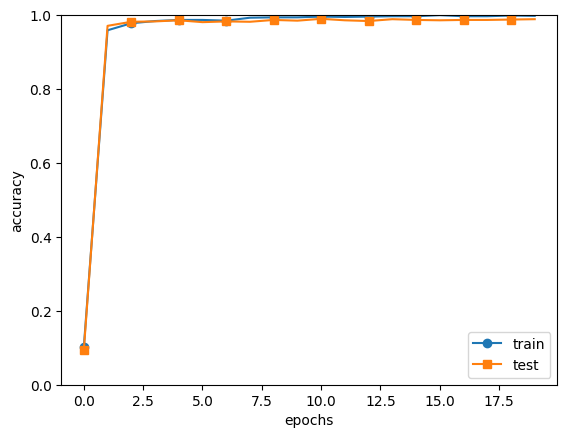

In [12]:
# coding: utf-8
import sys, os
sys.path.append(os.path.join(os.path.dirname(os.getcwd())))

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.trainer import Trainer

# 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=False)

# 시간이 오래 걸릴 경우 데이터를 줄인다.
#x_train, t_train = x_train[:5000], t_train[:5000]
#x_test, t_test = x_test[:1000], t_test[:1000]

max_epochs = 20

network = SimpleConvNet(input_dim=(1,28,28), 
                        conv_param = {'filter_num': 30, 'filter_size': 5, 'pad': 0, 'stride': 1},
                        hidden_size=100, output_size=10, weight_init_std=0.01)
                        
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=max_epochs, mini_batch_size=100,
                  optimizer='Adam', optimizer_param={'lr': 0.001},
                  evaluate_sample_num_per_epoch=1000)
trainer.train()

# 매개변수 보존
network.save_params("params.pkl")
print("Saved Network Parameters!")

# 그래프 그리기
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, trainer.train_acc_list, marker='o', label='train', markevery=2)
plt.plot(x, trainer.test_acc_list, marker='s', label='test', markevery=2)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

## 7.6 CNN 시각화하기
### 7.6.1 1번째 층의 가중치 시각화하기
앞의 MNIST 데이터셋으로 CNN학습을 해보았는데, 그때 1번째 층의 합성곱 계층의 가중치는 그 형상이 (30, 1, 5, 5)였음\
이는 필터 30개, 채널 1개, 5x5크기임을 뜻함\
필터의 크기가 5x5이고 채널이 1개라는 것은 이 필터를 1채널의 회색조 이미지로 시각화할 수 있다는 뜻임\
그럼 합성곱 계층(1층째) 필터를 이미지로 나타내볼 것임\
여기에서는 학습전과 후의 가중치를 비교해볼 것인데, 그 결과는 아래와 같음

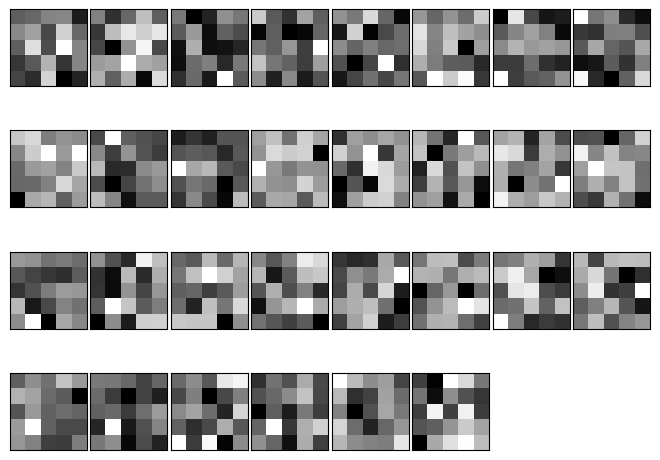

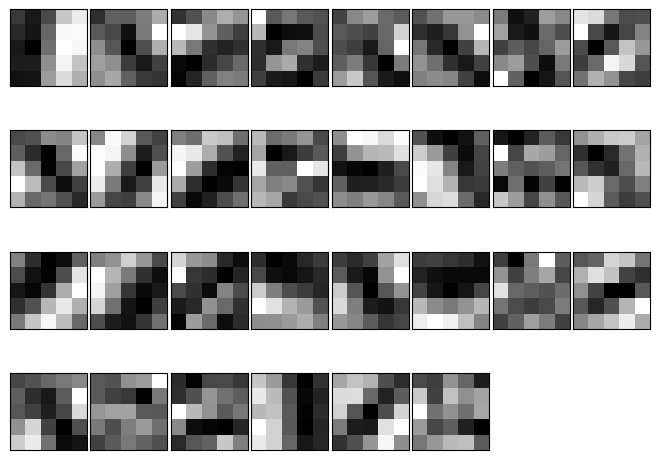

In [19]:
# coding: utf-8
import numpy as np
import matplotlib.pyplot as plt

def filter_show(filters, nx=8, margin=3, scale=10):
    """
    c.f. https://gist.github.com/aidiary/07d530d5e08011832b12#file-draw_weight-py
    """
    FN, C, FH, FW = filters.shape
    ny = int(np.ceil(FN / nx))

    fig = plt.figure()
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

    for i in range(FN):
        ax = fig.add_subplot(ny, nx, i+1, xticks=[], yticks=[])
        ax.imshow(filters[i, 0], cmap=plt.cm.gray_r, interpolation='nearest')
    plt.show()


network = SimpleConvNet()
# 무작위(랜덤) 초기화 후의 가중치
filter_show(network.params['W1'])

# 학습된 가중치
network.load_params("./DL/params.pkl")
filter_show(network.params['W1'])

학습 전 필터는 무작위로 초기화되고 있어 흑백의 정도에 규칙성이 없지만 학습을 마친 필터는 규칙성이 있는 이미지가 되었음\
흰색에서 검은색으로 점차 변화하는 필터와 덩어리(블롭, blob)가 진 필터 등 규칙을 띄는 필터로 바뀌었음\
학습 후와 같이 규칙성 있는 필터는 '무엇을 보고 있는'것인가?\
바로 에지(색상이 바뀐 경계선)와 블롭(국소적으로 덩어리진 영역) 등을 보고 있음\
가령 왼쪽 절반이 흰색이고 오른쪽 절반이 검은색인 필터는 세로 에지에 반응하는 필터임

<img src="../image/ch7_cnn_vis_filter.png" width="600" style="display:block; margin:auto;">

위 그림은 학습된 필터 2개를 선택하여 입력 이미지에 합성곱 처리를 한 결과로 '필터 1'은 세로 에지에 반응하며 '필터 2'는 가로 에지에 반응\
이처럼 합성곱 계층의 필터는 에지나 블롭 등의 원시적인 정보를 추출할 수 있음\
앞에서 구현한 CNN은 이런 원시적인 정보를 뒷단 계층으로 전달함

### 7.6.2 층 깊이에 따른 추출 정보 변화
앞 절의 결과는 1번째 층의 합성곱 계층을 대상으로 하였음\
1번째 층의 합성곱 계층에서는 에지나 블롭 등의 저수준 정보가 추출된다면, 겹겹이 쌓인 CNN의 각 계층에서는 어떤 정보가 추출되는가?\
딥러닝 시각화에 관한 연구에 따르면, 계층이 깊어질수록 추출되는 정보(정확히는 강하게 반응하는 뉴런)는 더 많이 추상화됨을 알 수 있음

<img src="../image/ch7_cnn_info_per_layer.png" width="800" style="display:block; margin:auto;">

위 그림은 일반 사물 인식을 수행한 8층의 CNN\
이 구조는 AlexNet이라 하는데, 합성곱 계층과 풀링 계층을 여러 겹 쌓고, 마지막으로 완전연결 계층을 거쳐 결과를 출력하는 구조\
블록은 중간 데이터이며, 그 중간 데이터에 합성곱 연산을 연속해서 적용함

딥러닝의 흥미로운 점은 위 그림과 같이 합성곱 계층을 여러 겹 쌓으면, 층이 깊어지면서 더 복잡하고 추상화된 정보가 추출된다는 것\
처음 층은 단순한 에지에 반응하고, 이어서 텍스쳐에 반응하고, 더 복잡한 사물의 일부에 반응하도록 변화함\
즉, 층이 깊어지면서 뉴런이 반응하는 대상이 단순한 모양에서 '고급' 정보로 변화해 감\
다시 말하면 사물의 '의미'를 이해하도록 변화하는 것

## 7.7 대표적인 CNN
### 7.7.1 LeNet
`LeNet`은 손글씨 숫자를 인식하는 신경망으로 1998년에 제안되었고 아래와 같이 합성곱 계층과 풀링 계층(정확히는 단순히 '원소를 줄이기'만 하는 서브샘플링 계층)을 반복하고, 마지막으로 완전연결 계층을 거치면서 결과를 출력함

<img src="../image/ch7_LeNet_architecture.png" width="800" style="display:block; margin:auto;">

LeNet과 '현재의 CNN'을 비교하면 몇 가지 면에서 차이가 존재함\
첫 번째 차이는 활성화 함수로, LeNet은 시그모이드 함수를 사용하는 데 반해, 현재는 주로 ReLU를 사용함\
또 원래의 LeNet은 서브샘플링을 하여 중간 데이터의 크기를 줄이지만 현재는 최대 풀링이 주류임

### 7.7.2 AlexNet
LeNet과 비교해 훨씬 최근인 2012년에 발표된 `AlexNet`은 딥러닝 열풍을 일으키는 데 큰 역할을 하였음

<img src="../image/ch7_AlexNet_architecture.jpg" width="800" style="display:block; margin:auto;">

AlexNet은 합성곱 계층과 풀링 계층을 거듭하며 마지막으로 완전연결 계층을 거쳐 결과를 출력함\
AlexNet은 LeNet과 비교할 때 큰 구조는 바뀌지 않았지만 다음과 같은 변화를 주었음
* 활성화 함수로 ReLU를 이용
* LRN(Local Response Normalization)이라는 국소적 정규화를 실시하는 계층을 이용
* 드롭아웃을 사용

## 7.8 정리
* CNN은 지금까지의 완전연결 계층 신경망에 합성곱 계층과 풀링 계층을 새로 추가함
* 합성곱 계층과 풀링 계층은 im2col(이미지를 행렬로 전개하는 함수)을 이용하면 간단하고 효율적으로 구현 가능
* CNN을 시각화해보면 계층이 깊어질수록 고급 정보가 추출되는 모습을 확인할 수 있음
* 대표적인 CNN에는 LeNet과 AlexNet이 있음